## Evaluating on test set

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from tqdm.notebook import tqdm
from models import DeepONet

# --- 1. CONFIGURAZIONE ---
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
torch.set_default_dtype(torch.float32)

output_dir = 'results_deeponet'
config_path = os.path.join(output_dir, 'config_deeponet.json')

if not os.path.exists(config_path):
    raise FileNotFoundError(f"Config file not found at {config_path}. Run train_deeponet.py first!")

with open(config_path, 'r') as f:
    config = json.load(f)

dt = config["DT"]
epsilon = config["EPSILON"]
N_NODES = config["N_NODES"]

# DeepONet Params
branch_hidden = config["branch_hidden"]
trunk_hidden = config["trunk_hidden"]
latent_dim = config["latent_dim"]
num_layers_mlp = config["num_layers_mlp"]

# --- 2. CARICAMENTO DATI TEST ---
print("Loading Test Data...")
if not os.path.exists('data/data_ac_graph_test.npy'):
    raise FileNotFoundError("Test data not found!")

sol_np = np.load('data/data_ac_graph_test.npy') 
graph_info = np.load('data/graph_info.npz')

eigenvalues_np = graph_info['eigenvalues']
eigenvectors_np = graph_info['eigenvectors']

# Preparazione Tensori
sol = torch.tensor(sol_np, dtype=torch.float32).to(device)
# Phi ed eigen servono per il solver IMEX ibrido
Phi = torch.tensor(eigenvectors_np, dtype=torch.float32).to(device)
eigen = torch.tensor(eigenvalues_np, dtype=torch.float32).to(device)

# Denominatore IMEX Euler
denom = (1 + epsilon**2 * dt * eigen)

num_test_samples = sol.shape[0]
num_steps = sol.shape[1] - 1
print(f"Test Data Shape: {sol.shape}")
print(f"Simulation Steps: {num_steps}")

Using device: cuda:0
Loading Test Data...
Test Data Shape: torch.Size([2000, 21, 1000])
Simulation Steps: 20


In [2]:
# --- 3. CARICAMENTO MODELLO ---
net = DeepONet(N_nodes=N_NODES, 
               branch_hidden=branch_hidden,
               trunk_hidden=trunk_hidden,
               latent_dim=latent_dim,
               num_layers=num_layers_mlp).to(device)

model_path = os.path.join(output_dir, 'deeponet_model.pth')
state_dict = torch.load(model_path, map_location=device)
net.load_state_dict(state_dict)
net.eval()

print("DeepONet Model loaded. Running evaluation loop...")

# Batching per evitare OOM sul test set se è grande
TEST_BATCH_SIZE = 200
all_preds = []
rel_errors = []

with torch.no_grad():
    for i in tqdm(range(0, num_test_samples, TEST_BATCH_SIZE), desc="Test Batches"):
        u_batch = sol[i:i+TEST_BATCH_SIZE]
        u_curr = u_batch[:, 0, :]
        
        batch_preds = [u_curr]
        
        for step in range(num_steps):
            # 1. DeepONet Prediction (Reazione)
            nonlinearity_phys = net(u_curr)
            
            # 2. IMEX Step (Diffusione esatta)
            nonlin_spec = nonlinearity_phys @ Phi
            u_curr_spec = u_curr @ Phi
            
            u_next_spec = (u_curr_spec + dt * nonlin_spec) / denom
            u_next_phys = u_next_spec @ Phi.T
            
            batch_preds.append(u_next_phys)
            u_curr = u_next_phys

        # Stack -> (Batch, Time, Nodes)
        batch_preds_tensor = torch.stack(batch_preds, dim=1)
        all_preds.append(batch_preds_tensor)
        
        # Calcolo Errore Traiettoria per questo batch
        diff = batch_preds_tensor - u_batch
        flat_diff = diff.reshape(u_batch.shape[0], -1)
        flat_true = u_batch.reshape(u_batch.shape[0], -1)
        
        norm_diff = torch.norm(flat_diff, p=2, dim=1)
        norm_true = torch.norm(flat_true, p=2, dim=1)
        
        batch_rel_errs = (norm_diff / (norm_true + 1e-6)).cpu().numpy()
        rel_errors.extend(batch_rel_errs)

# Concatenazione di tutte le predizioni
preds = torch.cat(all_preds, dim=0)
rel_errors = np.array(rel_errors)

print("Evaluation complete.")

DeepONet Model loaded. Running evaluation loop...


/tmp/ipykernel_3200686/3775322468.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


Test Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluation complete.


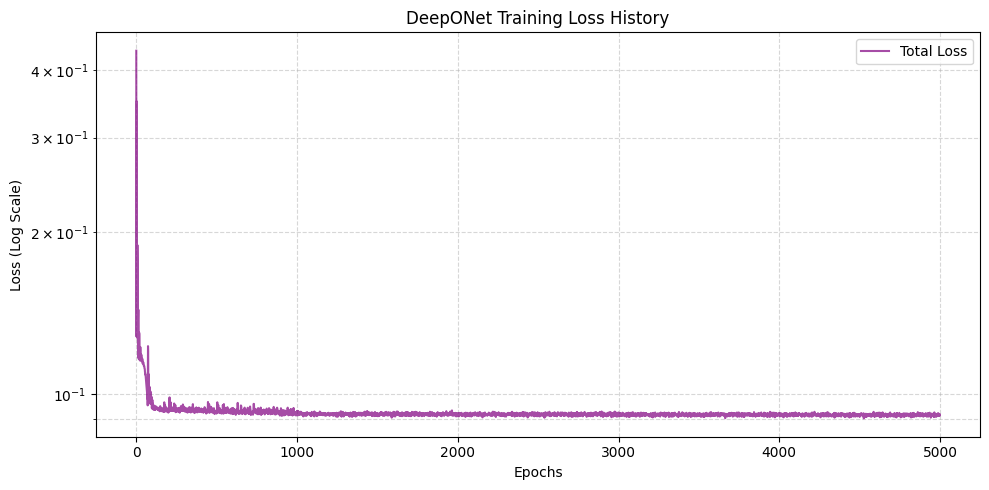

TEST SET RESULTS (DeepONet Blind)
Relative Trajectory Error:   0.0675 ± 0.0037
Accuracy (1 - RelErr):       93.25%


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. LOAD TRAINING HISTORY ---
# Assicuriamoci che output_dir sia definito (dalle celle precedenti)
loss_file_path = os.path.join(output_dir, 'loss_history.npy')

if os.path.exists(loss_file_path):
    loss_history = np.load(loss_file_path)

    # --- 2. PLOT TRAINING HISTORY (Stile Standardizzato) ---
    plt.figure(figsize=(10, 5))
    # Colore 'purple' per uniformità con gli altri plot
    plt.plot(loss_history, label='Total Loss', color='purple', alpha=0.7)
    plt.yscale('log')
    plt.title('DeepONet Training Loss History')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Log Scale)')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ Attenzione: File loss non trovato in {loss_file_path}")

# --- 3. PRINT METRICS (Format Standardizzato) ---
mean_traj_err = np.mean(rel_errors)
std_traj_err = np.std(rel_errors)

print("="*40)
print("TEST SET RESULTS (DeepONet Blind)")
print("="*40)
# Se hai calcolato l'MSE in precedenza (es. global_mse), lo stampiamo, altrimenti lo saltiamo
if 'global_mse' in locals():
    print(f"Average MSE Error:           {global_mse:.2e}")
elif 'mean_res_error' in locals():
    print(f"Average MSE Error:           {mean_res_error:.2e}")

print(f"Relative Trajectory Error:   {mean_traj_err:.4f} ± {std_traj_err:.4f}")
print(f"Accuracy (1 - RelErr):       {(1-mean_traj_err)*100:.2f}%")
print("="*40)

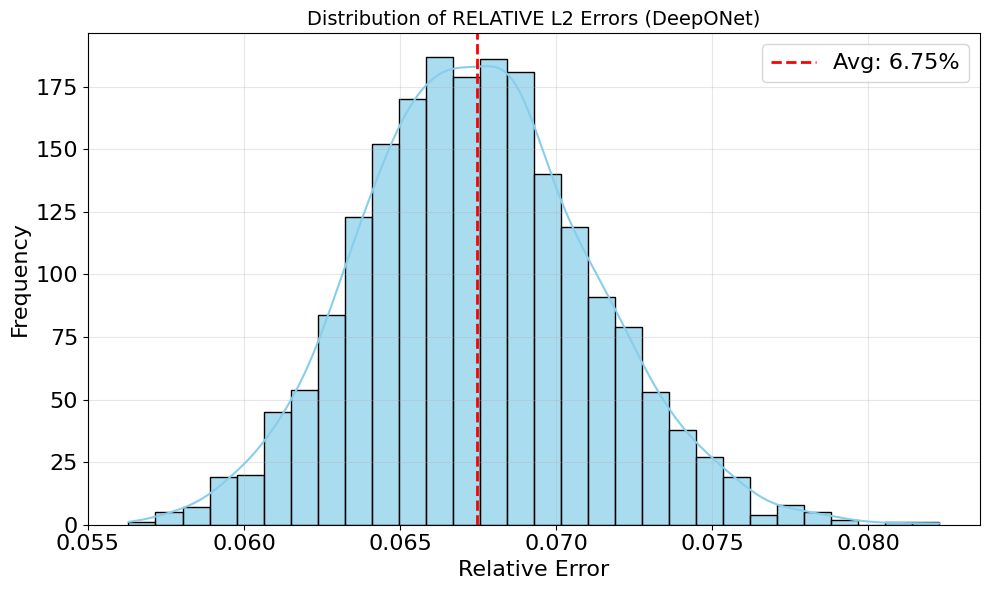

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- IMPOSTAZIONI ---
arch_name = "DeepONet" 

# --- PLOT STANDARD ---
plt.figure(figsize=(10, 6))

# Istogramma con stile standard (skyblue)
sns.histplot(rel_errors, bins=30, kde=True, color='skyblue', edgecolor='black', alpha=0.7)

# Linea della media (formattata come percentuale per coerenza)
plt.axvline(mean_traj_err, color='red', linestyle='--', linewidth=2, label=f'Avg: {mean_traj_err:.2%}')

# Titolo dinamico
plt.title(f'Distribution of RELATIVE L2 Errors ({arch_name})', fontsize=14)

# --- FONT SIZE & LABEL FIX ---
plt.xlabel('Relative Error', fontsize=16)     # Aumentato font label
plt.ylabel('Frequency', fontsize=16)          # Aumentato font label
plt.legend(fontsize=16)                       # Aumentato font legenda
plt.tick_params(axis='both', which='major', labelsize=16) # Aumentato font numeri assi

# --- FORMATTAZIONE ASSE X (STANDARD/PLAIN) ---
# Rimossa notazione scientifica, uso stile 'plain'
plt.ticklabel_format(style='plain', axis='x') 

# Nota: La riga per get_offset_text().set_fontsize() non serve più 
# perché non c'è il moltiplicatore (es. 1e-2)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

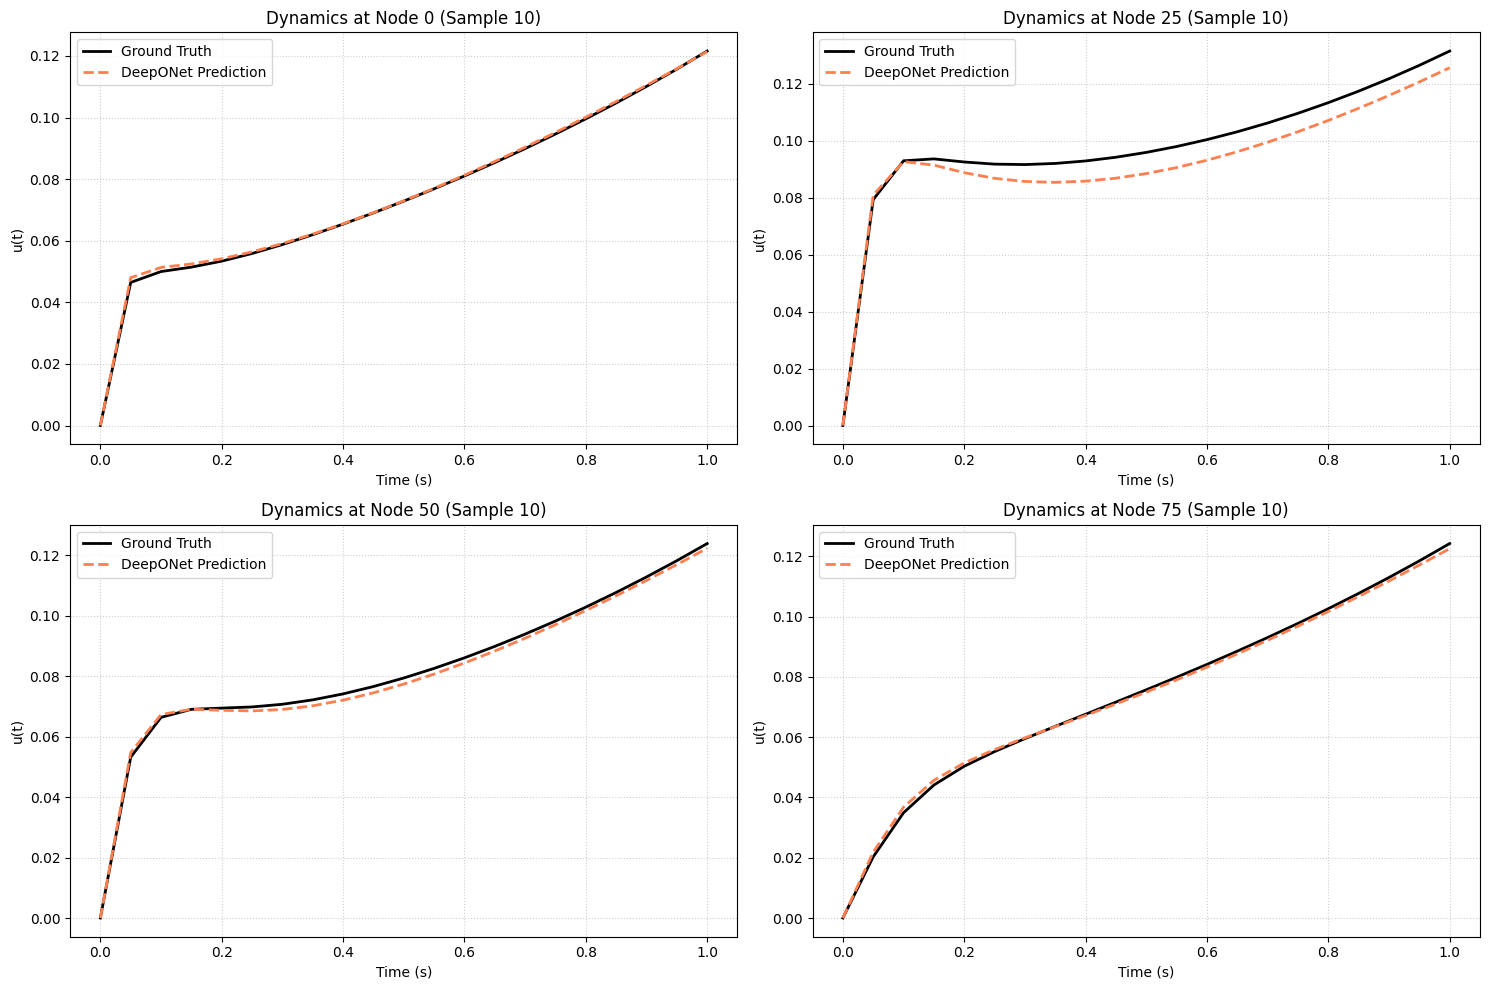

In [5]:
# --- NODE DYNAMICS PLOT ---
sample_idx = 10  # Indice del campione da visualizzare
nodes_to_plot = [0, 25, 50, 75] # Nodi sparsi
time_axis = np.arange(num_steps + 1) * dt

plt.figure(figsize=(15, 10))

for i, node_idx in enumerate(nodes_to_plot):
    plt.subplot(2, 2, i+1)
    
    y_true = sol[sample_idx, :, node_idx].cpu().numpy()
    y_pred = preds[sample_idx, :, node_idx].cpu().numpy()
    
    plt.plot(time_axis, y_true, 'k-', linewidth=2, label='Ground Truth')
    plt.plot(time_axis, y_pred, color='coral', linestyle='--', linewidth=2, label='DeepONet Prediction')
    
    plt.title(f'Dynamics at Node {node_idx} (Sample {sample_idx})')
    plt.xlabel('Time (s)')
    plt.ylabel('u(t)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()